In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("netflix_titles.csv")

In [3]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


### Here date_added and release year are in object  we have to change into date_time

In [6]:
df["date_added"] = pd.to_datetime(
    df["date_added"].str.strip(),
    errors="coerce"
)
#.str.strip() removes leading/trailing spaces
#errors="coerce" converts invalid values to NaT instead of crashing

In [7]:
df["release_year"]=pd.to_datetime(df["release_year"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   datetime64[ns]
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](2), object(10)
memory usage: 825.8+ KB


### checking null values and Handling of null values

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df["director"]=df["director"].fillna("Not Available")
df["cast"]=df["cast"].fillna("Not Available")
df["country"]=df["country"].fillna("Not Available")
df["date_added"]=df["date_added"].fillna("Not Available")
 

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64

In [14]:
df = df.dropna(subset=["rating"])

In [15]:
df = df.dropna(subset=["duration"])

In [16]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [17]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [18]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8800 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8800 non-null   object        
 1   type          8800 non-null   object        
 2   title         8800 non-null   object        
 3   director      8800 non-null   object        
 4   cast          8800 non-null   object        
 5   country       8800 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8800 non-null   datetime64[ns]
 8   rating        8800 non-null   object        
 9   duration      8800 non-null   object        
 10  listed_in     8800 non-null   object        
 11  description   8800 non-null   object        
dtypes: datetime64[ns](2), object(10)
memory usage: 893.8+ KB


### Remove Unwanted Spaces
### Convert Categorical Values to Lowercase
### Standardizing Categorical Values

In [20]:
category_columns = ["country","type","rating","listed_in"]

for col in category_columns:
    df[col] = df[col].str.strip()      # remove unwanted spaces
    df[col] = df[col].str.lower()      # convert to lowercase

In [21]:
df['type'].unique()

array(['movie', 'tv show'], dtype=object)

In [22]:
df['type'].value_counts()

type
movie      6126
tv show    2674
Name: count, dtype: int64

#### so in this type column there is no inconsistencies

#### Handling country column

In [23]:
df['country'].unique()

array(['united states', 'south africa', 'not available', 'india',
       'united states, ghana, burkina faso, united kingdom, germany, ethiopia',
       'united kingdom', 'germany, czech republic', 'mexico', 'turkey',
       'australia', 'united states, india, france', 'finland',
       'china, canada, united states',
       'south africa, united states, japan', 'nigeria', 'japan',
       'spain, united states', 'france', 'belgium',
       'united kingdom, united states', 'united states, united kingdom',
       'france, united states', 'south korea', 'spain',
       'united states, singapore', 'united kingdom, australia, france',
       'united kingdom, australia, france, united states',
       'united states, canada', 'germany, united states',
       'south africa, united states', 'united states, mexico',
       'united states, italy, france, japan',
       'united states, italy, romania, united kingdom',
       'australia, united states', 'argentina, venezuela',
       'united states

In [24]:
df["country"] = df["country"].str.split(",")
df = df.explode("country")
df["country"] = df["country"].str.strip()

#### Replace Empty values with not_available

In [25]:
df["country"]=df["country"].replace('','not_available')

In [26]:
pd.set_option('display.max_rows', None)

In [27]:
df['country'].value_counts()

country
united states           3687
india                   1046
not available            830
united kingdom           806
canada                   445
france                   393
japan                    317
spain                    232
south korea              231
germany                  226
mexico                   169
china                    162
australia                159
egypt                    117
turkey                   113
hong kong                105
nigeria                  103
italy                     99
brazil                    97
argentina                 91
belgium                   90
indonesia                 90
taiwan                    89
philippines               83
thailand                  70
south africa              62
colombia                  52
netherlands               50
denmark                   48
ireland                   46
sweden                    42
poland                    41
singapore                 41
united arab emirates      37
new ze

#### Handling rating column

In [28]:
df["rating"].unique()

array(['pg-13', 'tv-ma', 'pg', 'tv-14', 'tv-pg', 'tv-y', 'tv-y7', 'r',
       'tv-g', 'g', 'nc-17', 'nr', 'tv-y7-fv', 'ur'], dtype=object)

In [29]:
df["rating"].value_counts()

rating
tv-ma       3755
tv-14       2406
r           1236
tv-pg       1002
pg-13        769
tv-y7        431
pg           429
tv-y         382
tv-g         244
nr           110
g             62
tv-y7-fv       8
nc-17          5
ur             4
Name: count, dtype: int64

#### Handling listed_in column

In [30]:
df["listed_in"].unique()

array(['documentaries', 'international tv shows, tv dramas, tv mysteries',
       'crime tv shows, international tv shows, tv action & adventure',
       'docuseries, reality tv',
       'international tv shows, romantic tv shows, tv comedies',
       'tv dramas, tv horror, tv mysteries', 'children & family movies',
       'dramas, independent movies, international movies',
       'british tv shows, reality tv', 'comedies, dramas',
       'crime tv shows, docuseries, international tv shows',
       'dramas, international movies',
       'children & family movies, comedies',
       'british tv shows, crime tv shows, docuseries',
       'tv comedies, tv dramas', 'documentaries, international movies',
       'crime tv shows, spanish-language tv shows, tv dramas',
       'thrillers',
       'international tv shows, spanish-language tv shows, tv action & adventure',
       'international tv shows, tv action & adventure, tv dramas',
       'comedies, international movies',
       'comedies, 

In [31]:
df["listed_in"] = df["listed_in"].str.lower().str.strip()
df["listed_in"] = df["listed_in"].str.split(",")
df = df.explode("listed_in")
df["listed_in"] = df["listed_in"].str.strip()

In [32]:
df['listed_in'].value_counts()

listed_in
international movies            3513
dramas                          3201
comedies                        1981
international tv shows          1464
action & adventure              1182
documentaries                   1118
independent movies              1040
tv dramas                        852
children & family movies         845
thrillers                        806
romantic movies                  722
tv comedies                      629
kids' tv                         595
crime tv shows                   541
horror movies                    458
docuseries                       436
music & musicals                 429
romantic tv shows                384
sci-fi & fantasy                 380
stand-up comedy                  344
british tv shows                 306
reality tv                       270
sports movies                    265
tv action & adventure            204
spanish-language tv shows        202
anime series                     191
korean tv shows             

#### Checking for Duplicates

In [33]:
df.duplicated().any()

np.False_

### Duration column consists of tv_shows=seasons and movies=minutes so we need to separate into two columns and fill missing values with not available

In [34]:
print(df["duration"])

0           90 min
1        2 Seasons
1        2 Seasons
1        2 Seasons
2         1 Season
2         1 Season
2         1 Season
3         1 Season
3         1 Season
4        2 Seasons
4        2 Seasons
4        2 Seasons
5         1 Season
5         1 Season
5         1 Season
6           91 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
7          125 min
8        9 Seasons
8        9 Seasons
9          104 min
9          104 min
10        1 Season
10        1 Season
10        1 Season
11        1 Season
11        1 Season
11        1 Season
12         127 min
12         127 min
12         127 min
12         127 min
13          91 min
13          91 min
14        1 Season
14        1 Season
14        1 

In [35]:
df["duration_minutes"] = df["duration"].str.extract(r"(\d+) min")
df["duration_seasons"] = df["duration"].str.extract(r"(\d+) Season")

df["duration_minutes"] = df["duration_minutes"].fillna("not available")
df["duration_seasons"] = df["duration_seasons"].fillna("not available")

In [36]:
df=df.drop("duration",axis=1)

In [37]:
df.duplicated().any()

np.False_

In [38]:
df.isnull().any()

show_id             False
type                False
title               False
director            False
cast                False
country             False
date_added           True
release_year        False
rating              False
listed_in           False
description         False
duration_minutes    False
duration_seasons    False
dtype: bool

In [36]:
df["date_added"]=df["date_added"].fillna("Not Available")

In [39]:
df.head(1)


,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_minutes,duration_seasons
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,1970-01-01 00:00:00.000002020,pg-13,documentaries,"As her father nears the end of his life, filmm...",90,not available


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23755 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           23755 non-null  object        
 1   type              23755 non-null  object        
 2   title             23755 non-null  object        
 3   director          23755 non-null  object        
 4   cast              23755 non-null  object        
 5   country           23755 non-null  object        
 6   date_added        23735 non-null  datetime64[ns]
 7   release_year      23755 non-null  datetime64[ns]
 8   rating            23755 non-null  object        
 9   listed_in         23755 non-null  object        
 10  description       23755 non-null  object        
 11  duration_minutes  23755 non-null  object        
 12  duration_seasons  23755 non-null  object        
dtypes: datetime64[ns](2), object(11)
memory usage: 2.5+ MB


### Analyze Netflix Content Growth overtime


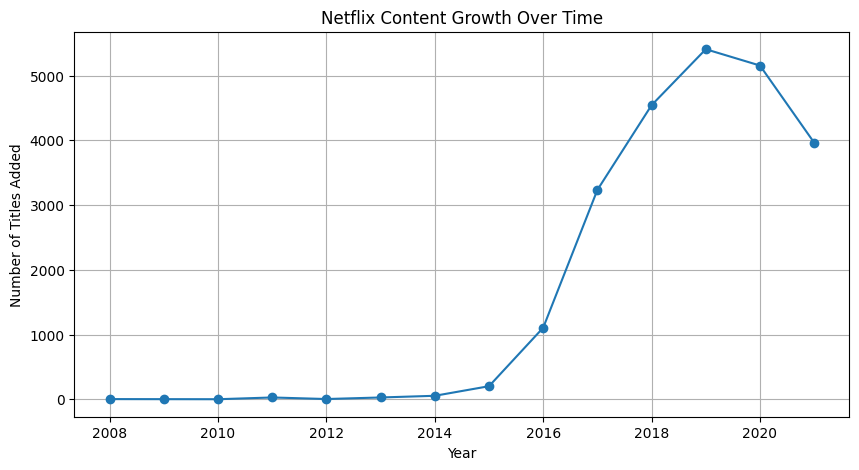

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

content_growth = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(content_growth.index, content_growth.values, marker='o')
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)
plt.show()

### Distribution of Content Type

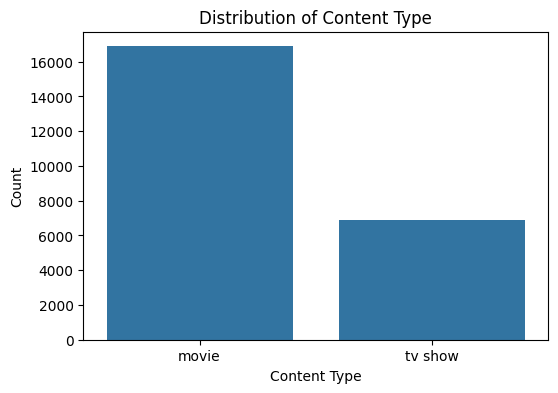

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title("Distribution of Content Type")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

### Distribution of Ratings

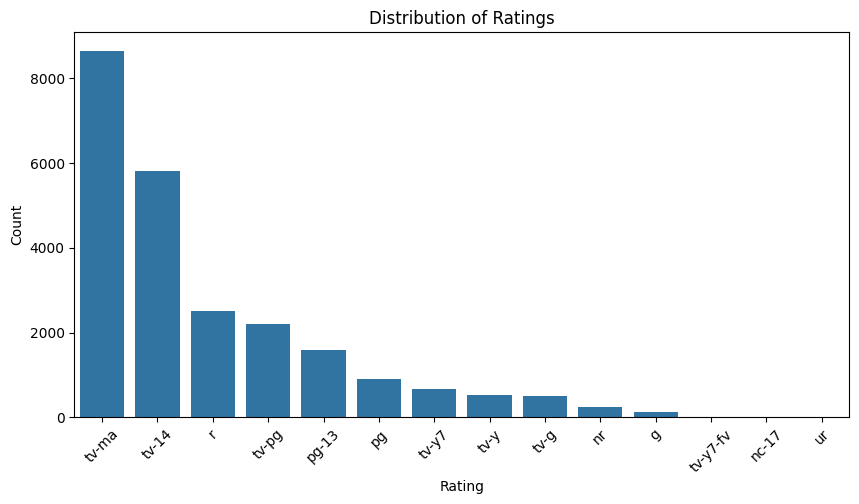

In [43]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Distribution of Genres

In [44]:
df['listed_in'] = df['listed_in'].str.split(',')

df_genre = df.explode('listed_in')

df_genre['listed_in'] = df_genre['listed_in'].str.strip()

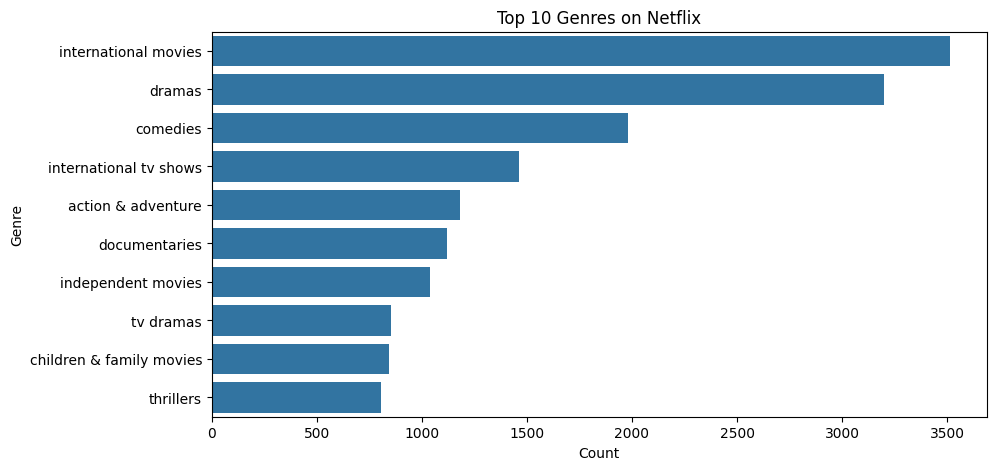

In [45]:
top_genres = df_genre['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

### Identify country-level content contributions. 

In [46]:
top_countries = df['country'].value_counts().head(10)

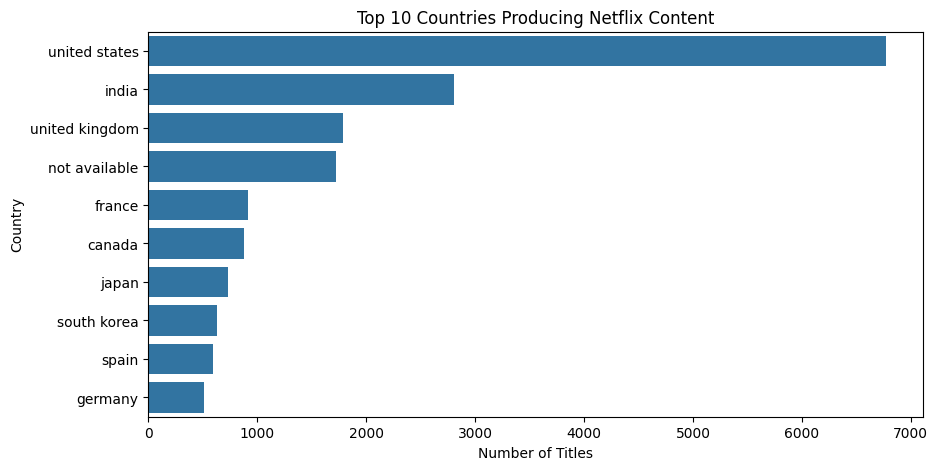

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

### Create derived features such as “Content Length Category” and “Original vs. Licensed” (if derivable from dataset).

In [48]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_minutes,duration_seasons
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,1970-01-01 00:00:00.000002020,pg-13,[documentaries],"As her father nears the end of his life, filmm...",90,not available


### Content Length Category

In [49]:
df['duration_minutes'] = pd.to_numeric(df['duration_minutes'], errors='coerce')

In [50]:
def content_length_category(x):
    if x <= 60:
        return "Short"
    elif x <= 120:
        return "Medium"
    elif x > 120:
        return "Long"
    else:
        return "Unknown"

df['content_length_category'] = df['duration_minutes'].apply(content_length_category)

In [51]:
df[['duration_minutes','content_length_category']].head(1)

,duration_minutes,content_length_category
0,90.0,Medium


### Original vs. Licensed

In [52]:
df['content_origin'] = df['description'].apply(
    lambda x: "Original" if "netflix" in str(x).lower() else "Licensed"
)

In [53]:
df['content_length_category'].value_counts()
df['content_origin'].value_counts()

content_origin
Licensed    23741
Original       14
Name: count, dtype: int64

### Clustering Netflix Titles
#### Goal: Group similar titles together based on features.

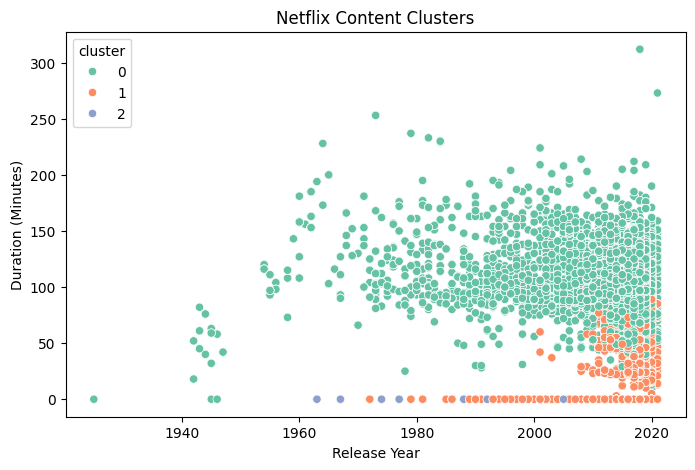

cluster
0    16134
1     6974
2      647
Name: count, dtype: int64


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

# -------------------------------
# Data Cleaning
# -------------------------------

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year added
df['year_added'] = df['date_added'].dt.year

# Ensure release_year is numeric
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

# Convert duration_seasons to numeric
df['duration_seasons'] = pd.to_numeric(df['duration_seasons'], errors='coerce')

# Replace missing values
df['duration_seasons'] = df['duration_seasons'].fillna(0)
df['duration_minutes'] = df['duration_minutes'].fillna(0)

# -------------------------------
# Encode categorical column
# -------------------------------

le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'].astype(str))

# -------------------------------
# Feature Selection
# -------------------------------

features = df[['release_year','duration_minutes','duration_seasons','rating_encoded']]

# Fill missing values
features = features.fillna(features.mean())

# -------------------------------
# Feature Scaling
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# -------------------------------
# K-Means Clustering
# -------------------------------

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# -------------------------------
# Visualization
# -------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['release_year'],
    y=df['duration_minutes'],
    hue=df['cluster'],
    palette='Set2'
)

plt.title("Netflix Content Clusters")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.show()

# -------------------------------
# Cluster distribution
# -------------------------------

print(df['cluster'].value_counts())

### "K-Means clustering was used to group Netflix titles based on release year, duration, and rating. The algorithm identified clusters of similar content patterns."

### Classification of content type (Movie vs TV Show) based on features

Accuracy: 1.0

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3382
           1       1.00      1.00      1.00      1369

    accuracy                           1.00      4751
   macro avg       1.00      1.00      1.00      4751
weighted avg       1.00      1.00      1.00      4751



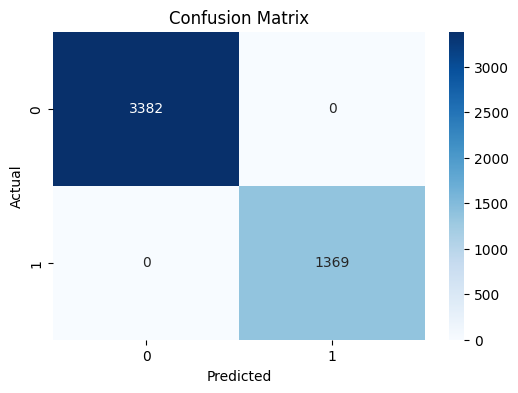

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Encode target variable
df['type_encoded'] = df['type'].map({'movie':0, 'tv show':1})

# Select features
features = df[['release_year','duration_minutes','rating_encoded']]
target = df['type_encoded']

# Handle missing values
features = features.fillna(features.mean())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()